# Análise — Reflection-MCQ

Parte 1: reprodução dos resultados do paper original (AGENTICS 2025) com os dados da extensão atual.
Parte 2: extensões definidas no `Caderno de Experimentos.md` (seção 5, métricas).

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
ANALYSIS = RESULTS / "analysis"
REFLECTIONS_DIR = RESULTS / "reflections"

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)

# gpt-5-petrobras só atua como professor (reflexão externa); nome de exibição curto.
TEACHER_LABEL = {"gpt-5-petrobras": "gpt-5"}


def display_teacher(t):
    return TEACHER_LABEL.get(t, t)

## Parte 1 — Reprodução do paper

### Acurácia por condição e modelo

Paper: Tabelas 2–3 (acurácia geral) e 4–5 (acurácia só sobre respostas válidas). Lá o eixo era
`approach × attempt`; aqui, com recuperação por similaridade em vez de segunda tentativa na mesma
questão, o eixo equivalente é `student × condition`.

In [2]:
acc = pd.read_csv(ANALYSIS / "accuracy.csv")
acc_test = acc[acc["split"] == "test"]

acc_by_cond = (
    acc_test.groupby(["student", "condition"])
    .apply(lambda g: pd.Series({
        "accuracy": g["n_correct"].sum() / g["n"].sum(),
        "accuracy_answered": g["n_correct"].sum() / g["n_answered"].sum(),
        "n": g["n"].sum(),
    }))
    .reset_index()
)

# Tabelas 2-3 do paper: acurácia geral por approach
acc_by_cond.pivot(index="student", columns="condition", values="accuracy").round(4)

condition,external_reflection,no_reflection,retry_feedback,self_reflection
student,,,,
llama3-8b,0.6027,0.7340,0.8623,0.5668
mistral-7b,0.5187,0.5497,0.7503,0.5212
phi4-mini,0.7460,0.7642,0.8777,0.7573
qwen3-8b,0.8632,0.8746,0.9494,0.8670


In [3]:
# Tabelas 4-5 do paper: acurácia considerando só respostas válidas (sem abstenção)
acc_by_cond.pivot(index="student", columns="condition", values="accuracy_answered").round(4)

condition,external_reflection,no_reflection,retry_feedback,self_reflection
student,,,,
llama3-8b,0.6865,0.7397,0.8630,0.6651
mistral-7b,0.5204,0.5523,0.7510,0.5223
phi4-mini,0.7628,0.7783,0.8883,0.7703
qwen3-8b,0.8674,0.8805,0.9514,0.8708


### Acurácia por dataset

Mesmas Tabelas 2–5, quebradas por dataset em vez de agregadas — o paper só tinha ARC.

In [4]:
acc_by_ds = (
    acc_test.groupby(["dataset", "student", "condition"])
    .apply(lambda g: pd.Series({
        "accuracy": g["n_correct"].sum() / g["n"].sum(),
        "accuracy_answered": g["n_correct"].sum() / g["n_answered"].sum(),
    }))
    .reset_index()
)

# Tabelas 2-3 por dataset
acc_by_ds.pivot(index=["dataset", "student"], columns="condition", values="accuracy").round(4)

condition              external_reflection  no_reflection  retry_feedback  \
dataset    student                                                          
aqua       llama3-8b                0.3916         0.5325          0.6707   
           mistral-7b               0.2561         0.2724          0.4959   
           phi4-mini                0.7073         0.7317          0.8130   
           qwen3-8b                 0.8367         0.8496          0.9065   
arc        llama3-8b                0.7291         0.8335          0.9317   
           mistral-7b               0.7385         0.7267          0.8813   
           phi4-mini                0.8745         0.8933          0.9590   
           qwen3-8b                 0.9325         0.9377          0.9855   
gsm8k      llama3-8b                0.7213         0.8726          0.9530   
           mistral-7b               0.3397         0.4473          0.6740   
           phi4-mini                0.8648         0.8961          0.9568   
           qwen3-8b                 0.9625         0.9682          0.9924   
logiqa2    llama3-8b                0.4083         0.5470          0.7406   
           mistral-7b               0.4884         0.4939          0.7150   
           phi4-mini                0.5267         0.5348          0.7457   
           qwen3-8b                 0.7150         0.7374          0.8837   
openbookqa llama3-8b                0.7063         0.8200          0.9360   
           mistral-7b               0.7007         0.7160          0.8800   
           phi4-mini                0.8367         0.8480          0.9240   
           qwen3-8b                 0.9160         0.9220          0.9780   

condition              self_reflection  
dataset    student                      
aqua       llama3-8b            0.3293  
           mistral-7b           0.2358  
           phi4-mini            0.7073  
           qwen3-8b             0.8476  
arc        llama3-8b            0.7267  
           mistral-7b           0.7451  
           phi4-mini            0.8903  
           qwen3-8b             0.9351  
gsm8k      llama3-8b            0.6395  
           mistral-7b           0.3412  
           phi4-mini            0.8821  
           qwen3-8b             0.9666  
logiqa2    llama3-8b            0.3901  
           mistral-7b           0.4901  
           phi4-mini            0.5361  
           qwen3-8b             0.7188  
openbookqa llama3-8b            0.6700  
           mistral-7b           0.7100  
           phi4-mini            0.8340  
           qwen3-8b             0.9180

In [5]:
# Tabelas 4-5 por dataset (só respostas válidas)
acc_by_ds.pivot(index=["dataset", "student"], columns="condition", values="accuracy_answered").round(4)

condition              external_reflection  no_reflection  retry_feedback  \
dataset    student                                                          
aqua       llama3-8b                0.5035         0.5551          0.6762   
           mistral-7b               0.2600         0.2803          0.4980   
           phi4-mini                0.7751         0.8072          0.8734   
           qwen3-8b                 0.8685         0.8970          0.9215   
arc        llama3-8b                0.7938         0.8363          0.9317   
           mistral-7b               0.7409         0.7274          0.8813   
           phi4-mini                0.8766         0.8933          0.9598   
           qwen3-8b                 0.9325         0.9377          0.9855   
gsm8k      llama3-8b                0.8042         0.8786          0.9530   
           mistral-7b               0.3400         0.4518          0.6755   
           phi4-mini                0.9054         0.9388          0.9783   
           qwen3-8b                 0.9707         0.9748          0.9939   
logiqa2    llama3-8b                0.4925         0.5505          0.7410   
           mistral-7b               0.4894         0.4942          0.7155   
           phi4-mini                0.5326         0.5362          0.7505   
           qwen3-8b                 0.7162         0.7416          0.8860   
openbookqa llama3-8b                0.7557         0.8266          0.9379   
           mistral-7b               0.7056         0.7174          0.8800   
           phi4-mini                0.8454         0.8480          0.9240   
           qwen3-8b                 0.9166         0.9238          0.9780   

condition              self_reflection  
dataset    student                      
aqua       llama3-8b            0.4602  
           mistral-7b           0.2377  
           phi4-mini            0.7751  
           qwen3-8b             0.8761  
arc        llama3-8b            0.7880  
           mistral-7b           0.7464  
           phi4-mini            0.8918  
           qwen3-8b             0.9351  
gsm8k      llama3-8b            0.7240  
           mistral-7b           0.3414  
           phi4-mini            0.9125  
           qwen3-8b             0.9725  
logiqa2    llama3-8b            0.4967  
           mistral-7b           0.4904  
           phi4-mini            0.5399  
           qwen3-8b             0.7212  
openbookqa llama3-8b            0.7596  
           mistral-7b           0.7157  
           phi4-mini            0.8373  
           qwen3-8b             0.9180

### Acurácia da reflexão externa por professor

`external_reflection` acima agrega todos os professores. Aqui separado por professor — inclui o `gpt-5` (gpt-5-petrobras), que só atuou como professor, nunca como aluno.

In [6]:
acc_ext = acc_test[acc_test["condition"] == "external_reflection"].copy()
acc_ext["teacher_label"] = acc_ext["teacher"].map(display_teacher)

acc_ext_agg = (
    acc_ext.groupby(["student", "teacher_label"])
    .apply(lambda g: pd.Series({
        "accuracy": g["n_correct"].sum() / g["n"].sum(),
        "accuracy_answered": g["n_correct"].sum() / g["n_answered"].sum(),
    }))
    .reset_index()
)
acc_ext_agg.pivot(index="student", columns="teacher_label", values="accuracy").round(4)

teacher_label,llama3-8b,mistral-7b,phi4-mini,qwen3-8b
student,,,,
llama3-8b,NaN,0.6343,0.6325,0.5413
mistral-7b,0.5094,NaN,0.5251,0.5218
phi4-mini,0.7588,0.7521,NaN,0.7269
qwen3-8b,0.8632,0.8648,0.8617,NaN


In [7]:
acc_ext_by_ds = (
    acc_ext.groupby(["dataset", "student", "teacher_label"])
    .apply(lambda g: pd.Series({"accuracy": g["n_correct"].sum() / g["n"].sum()}))
    .reset_index()
)
acc_ext_by_ds.pivot(index=["dataset", "student"], columns="teacher_label", values="accuracy").round(4)

teacher_label          llama3-8b  mistral-7b  phi4-mini  qwen3-8b
dataset    student                                               
aqua       llama3-8b         NaN      0.3902     0.4207    0.3638
           mistral-7b     0.2480         NaN     0.2561    0.2642
           phi4-mini      0.7398      0.7033        NaN    0.6789
           qwen3-8b       0.8435      0.8313     0.8354       NaN
arc        llama3-8b         NaN      0.7733     0.7549    0.6593
           mistral-7b     0.7365         NaN     0.7383    0.7408
           phi4-mini      0.8898      0.8839        NaN    0.8497
           qwen3-8b       0.9295      0.9347     0.9334       NaN
gsm8k      llama3-8b         NaN      0.7570     0.7566    0.6501
           mistral-7b     0.3287         NaN     0.3541    0.3362
           phi4-mini      0.8848      0.8806        NaN    0.8290
           qwen3-8b       0.9583      0.9670     0.9621       NaN
logiqa2    llama3-8b         NaN      0.4316     0.4396    0.3537
           mistral-7b     0.4802         NaN     0.4904    0.4946
           phi4-mini      0.5332      0.5217        NaN    0.5252
           qwen3-8b       0.7182      0.7150     0.7118       NaN
openbookqa llama3-8b         NaN      0.7400     0.7260    0.6530
           mistral-7b     0.6740         NaN     0.7180    0.7100
           phi4-mini      0.8350      0.8500        NaN    0.8250
           qwen3-8b       0.9200      0.9170     0.9110       NaN

### Error loop

Paper: Tabelas 8–9 — quantas vezes o modelo repete a mesma resposta errada na segunda tentativa
sobre a mesma questão. O equivalente aqui é o controle `retry_feedback` (mesma questão, feedback de
erro, sem reflexão), colunas `error_loops` / `error_loop_rate` em `utility.csv`.

In [8]:
util = pd.read_csv(ANALYSIS / "utility.csv")
error_loops = util[util["condition"] == "retry_feedback"][
    ["student", "dataset", "error_loops", "error_loop_rate"]
]
error_loops.pivot(index="dataset", columns="student", values="error_loop_rate").round(4)

student,llama3-8b,mistral-7b,phi4-mini,qwen3-8b
dataset,,,,
aqua,0.0174,0.0056,0.0606,0.1081
arc,0.0154,0.0219,0.0800,0.0274
gsm8k,0.0060,0.0000,0.0146,0.0000
logiqa2,0.0099,0.0303,0.0371,0.0584
openbookqa,0.0111,0.0211,0.0789,0.0000


### Comprimento das reflexões

Paper: Figuras 7–8 (boxplots por tipo) e Tabelas 10–13 (estatísticas descritivas). Lá o eixo era
`LLM × SLM` cruzado com `simples × complexa`; aqui, com professor e aluno podendo ser qualquer um
dos modelos ativos, o eixo equivalente é `condição (self/external) × profundidade`.

In [9]:
def load_reflection_texts():
    rows = []
    for folder in sorted(p for p in REFLECTIONS_DIR.iterdir() if p.is_dir()):
        student, teacher, depth = folder.name.split("__")
        condition = "self_reflection" if student == teacher else "external_reflection"
        for path in sorted(folder.glob("*.jsonl")):
            dataset = path.stem
            with path.open(encoding="utf-8") as fh:
                for line in fh:
                    line = line.strip()
                    if not line:
                        continue
                    rec = json.loads(line)
                    text = rec.get("reflection_text") or ""
                    if not text:
                        continue
                    words = text.split()
                    rows.append({
                        "student": student, "teacher": teacher, "depth": depth,
                        "condition": condition, "dataset": dataset,
                        "n_words": len(words), "n_chars": len(text),
                        "ttr": len(set(w.lower() for w in words)) / max(len(words), 1),
                    })
    return pd.DataFrame(rows)

refl = load_reflection_texts()
label = {"self_reflection": "self", "external_reflection": "external"}
refl["type"] = refl["condition"].map(label) + "-" + refl["depth"]
refl.head()

,student,teacher,depth,condition,dataset,n_words,n_chars,ttr,type
0,llama3-8b,gpt-5-petrobras,complex,external_reflection,aqua,608,3754,0.490132,external-complex
1,llama3-8b,gpt-5-petrobras,complex,external_reflection,aqua,686,4751,0.539359,external-complex
2,llama3-8b,gpt-5-petrobras,complex,external_reflection,aqua,739,4466,0.464141,external-complex
3,llama3-8b,gpt-5-petrobras,complex,external_reflection,aqua,518,3466,0.583012,external-complex
4,llama3-8b,gpt-5-petrobras,complex,external_reflection,aqua,368,2406,0.635870,external-complex


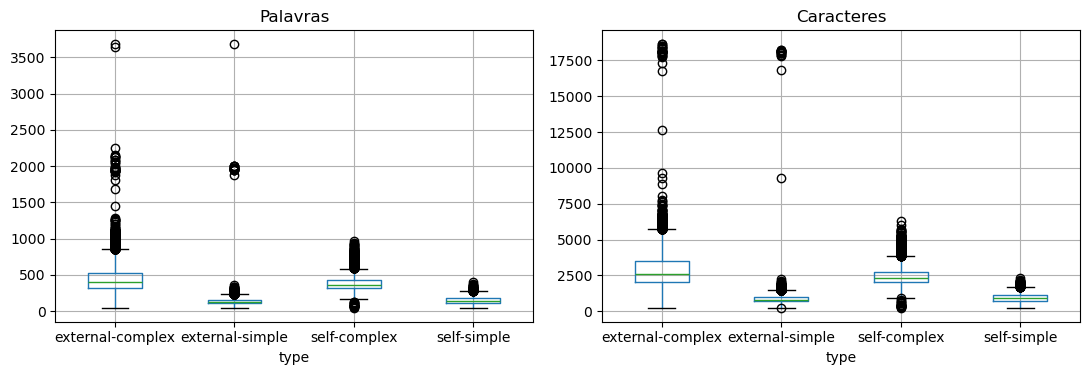

In [10]:
order = ["external-simple", "external-complex", "self-simple", "self-complex"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
refl.boxplot(column="n_words", by="type", ax=axes[0])
refl.boxplot(column="n_chars", by="type", ax=axes[1])
axes[0].set_title("Palavras"); axes[1].set_title("Caracteres")
fig.suptitle("")
plt.tight_layout()
plt.show()

In [11]:
refl.groupby("type")["n_words"].describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
external-complex,28208.0,434.69,179.89,38.0,311.0,395.0,528.0,3692.0
external-simple,28208.0,135.67,60.19,38.0,107.0,126.0,157.0,3690.0
self-complex,7052.0,383.88,98.34,35.0,319.0,365.0,426.0,965.0
self-simple,7052.0,149.69,43.88,35.0,114.0,144.0,178.0,399.0


In [12]:
refl.groupby("type")["n_chars"].describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
external-complex,28208.0,2842.82,1208.56,217.0,2011.0,2605.0,3491.0,18666.0
external-simple,28208.0,878.88,467.25,217.0,699.0,818.0,1007.0,18213.0
self-complex,7052.0,2470.75,653.01,195.0,2033.0,2320.0,2766.0,6307.0
self-simple,7052.0,942.52,265.23,195.0,731.0,910.0,1107.0,2296.0


### Comprimento das reflexões por dataset

Mesmas Tabelas 10–13, quebradas por dataset.

In [13]:
refl.groupby(["dataset", "type"])["n_words"].describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

count    mean     std    min    25%    50%  \
dataset    type                                                            
aqua       external-complex  6128.0  460.21  216.51   38.0  313.0  403.0   
           external-simple   6128.0  139.52   42.00   38.0  112.0  132.0   
           self-complex      1532.0  403.21  130.33   35.0  320.0  373.0   
           self-simple       1532.0  151.48   44.32   35.0  117.0  146.0   
arc        external-complex  4576.0  413.64  142.57   63.0  309.0  393.0   
           external-simple   4576.0  130.12   33.46   63.0  104.0  122.0   
           self-complex      1144.0  373.93   73.13  229.0  324.0  361.0   
           self-simple       1144.0  146.68   42.62   76.0  111.0  138.0   
gsm8k      external-complex  5856.0  404.99  171.11  136.0  300.0  376.0   
           external-simple   5856.0  133.20  108.63   63.0  104.0  120.0   
           self-complex      1464.0  366.37   89.12  178.0  305.0  349.0   
           self-simple       1464.0  143.04   42.61   66.0  107.0  138.5   
logiqa2    external-complex  5952.0  474.96  188.40  134.0  330.0  429.0   
           external-simple   5952.0  148.02   39.67   63.0  116.0  138.0   
           self-complex      1488.0  403.77   96.20  216.0  336.0  384.0   
           self-simple       1488.0  164.52   45.97   77.0  126.0  162.0   
openbookqa external-complex  5696.0  412.62  148.91  110.0  306.0  384.0   
           external-simple   5696.0  125.62   32.62   60.0  101.0  116.0   
           self-complex      1424.0  368.29   77.84  189.0  313.0  353.0   
           self-simple       1424.0  141.54   39.26   72.0  109.0  134.0   

                                75%     max  
dataset    type                              
aqua       external-complex  577.25  3647.0  
           external-simple   161.00  1879.0  
           self-complex      462.00   965.0  
           self-simple       178.00   399.0  
arc        external-complex  491.00   969.0  
           external-simple   153.00   281.0  
           self-complex      409.00   665.0  
           self-simple       173.00   315.0  
gsm8k      external-complex  463.00  3692.0  
           external-simple   148.00  3690.0  
           self-complex      411.00   827.0  
           self-simple       171.00   352.0  
logiqa2    external-complex  612.00  1256.0  
           external-simple   176.00   357.0  
           self-complex      444.00   890.0  
           self-simple       194.00   377.0  
openbookqa external-complex  492.00  1045.0  
           external-simple   147.00   264.0  
           self-complex      409.00   719.0  
           self-simple       167.00   300.0

In [14]:
refl.groupby(["dataset", "type"])["n_chars"].describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

count     mean      std     min      25%  \
dataset    type                                                          
aqua       external-complex  6128.0  2910.66  1396.26   217.0  1984.00   
           external-simple   6128.0   876.43   243.38   217.0   712.00   
           self-complex      1532.0  2542.39   840.46   195.0  1996.00   
           self-simple       1532.0   930.09   257.63   195.0   732.00   
arc        external-complex  4576.0  2769.55   978.50   339.0  2029.00   
           external-simple   4576.0   857.53   208.97   339.0   698.00   
           self-complex      1144.0  2432.92   509.26  1450.0  2088.75   
           self-simple       1144.0   938.78   257.86   514.0   730.00   
gsm8k      external-complex  5856.0  2616.59  1224.89   891.0  1914.75   
           external-simple   5856.0   855.35   916.14   368.0   665.00   
           self-complex      1464.0  2343.04   592.50  1098.0  1938.75   
           self-simple       1464.0   887.19   246.39   377.0   675.75   
logiqa2    external-complex  5952.0  3150.27  1255.56   931.0  2171.00   
           external-simple   5952.0   976.40   249.79   410.0   783.00   
           self-complex      1488.0  2641.37   651.45  1443.0  2184.00   
           self-simple       1488.0  1056.92   286.71   543.0   816.75   
openbookqa external-complex  5696.0  2740.00  1003.32   722.0  1987.75   
           external-simple   5696.0   820.98   200.52   382.0   671.00   
           self-complex      1424.0  2377.10   526.86  1224.0  2006.00   
           self-simple       1424.0   896.22   237.23   478.0   707.75   

                                50%      75%      max  
dataset    type                                        
aqua       external-complex  2600.5  3651.00  18666.0  
           external-simple    827.0  1010.00   9278.0  
           self-complex      2346.0  2940.50   6307.0  
           self-simple        916.0  1085.00   2083.0  
arc        external-complex  2636.0  3384.00   6524.0  
           external-simple    809.0   991.00   1831.0  
           self-complex      2317.0  2676.50   4440.0  
           self-simple        898.0  1099.00   1933.0  
gsm8k      external-complex  2445.5  3005.25  18174.0  
           external-simple    761.0   932.25  18213.0  
           self-complex      2207.5  2642.00   5254.0  
           self-simple        866.0  1057.00   2120.0  
logiqa2    external-complex  2850.0  4114.25   8010.0  
           external-simple    919.0  1145.00   2272.0  
           self-complex      2486.5  2946.75   5635.0  
           self-simple       1042.0  1242.00   2296.0  
openbookqa external-complex  2575.5  3361.25   6761.0  
           external-simple    769.0   948.00   1653.0  
           self-complex      2258.5  2642.25   4728.0  
           self-simple        850.0  1039.00   1921.0

### Diversidade lexical (TTR)

Paper: Figura 9.

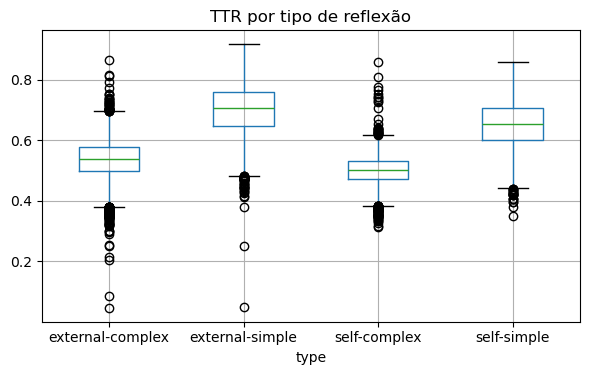

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
refl.boxplot(column="ttr", by="type", ax=ax)
ax.set_title("TTR por tipo de reflexão")
fig.suptitle("")
plt.tight_layout()
plt.show()

### Diversidade lexical por dataset

Mesma Figura 9, quebrada por dataset.

In [16]:
refl.groupby(["dataset", "type"])["ttr"].agg(["mean", "std"]).round(4)

mean     std
dataset    type                            
aqua       external-complex  0.5208  0.0641
           external-simple   0.6824  0.0729
           self-complex      0.4890  0.0541
           self-simple       0.6352  0.0749
arc        external-complex  0.5462  0.0532
           external-simple   0.7135  0.0726
           self-complex      0.5041  0.0392
           self-simple       0.6576  0.0731
gsm8k      external-complex  0.5489  0.0543
           external-simple   0.7083  0.0708
           self-complex      0.5099  0.0458
           self-simple       0.6603  0.0773
logiqa2    external-complex  0.5177  0.0576
           external-simple   0.6859  0.0753
           self-complex      0.4862  0.0419
           self-simple       0.6374  0.0692
openbookqa external-complex  0.5529  0.0554
           external-simple   0.7256  0.0709
           self-complex      0.5118  0.0410
           self-simple       0.6705  0.0663

### Reflexão externa por professor

Comprimento e TTR das reflexões, só da condição `external_reflection`, por professor — inclui o `gpt-5`.

In [17]:
refl_ext = refl[refl["condition"] == "external_reflection"].copy()
refl_ext["teacher_label"] = refl_ext["teacher"].map(display_teacher)
refl_ext.groupby(["teacher_label", "depth"])[["n_words", "n_chars", "ttr"]].mean().round(3)

n_words   n_chars    ttr
teacher_label depth                            
gpt-5         complex  510.162  3394.208  0.559
              simple   116.903   771.454  0.765
llama3-8b     complex  346.476  2216.284  0.525
              simple   171.718  1082.422  0.630
mistral-7b    complex  245.667  1563.846  0.583
              simple   144.590   908.762  0.670
phi4-mini     complex  383.465  2576.057  0.535
              simple   147.175   991.402  0.689
qwen3-8b      complex  662.546  4279.901  0.473
              simple   104.220   676.189  0.736

### Não reproduzido

- **Correlação semântica reflexão↔questão de origem** (paper: Fig. 3–6): exige o embedding da
  própria reflexão contra a questão que a gerou. `results/index/` só guarda embeddings das
  questões, não das reflexões — dado não disponível sem gerar novos embeddings.
- **Tabelas 6–7** (acurácia no subconjunto pareado de respostas válidas na 2ª tentativa): o
  protocolo do paper era responder a mesma questão duas vezes; aqui a avaliação injeta reflexões
  recuperadas por similaridade numa questão nova, então o pareamento por "resposta válida em
  ambas as abordagens sobre o mesmo item" não tem equivalente direto.

## Parte 2 — Extensões (Caderno, seção 5)

### Reflection utility

Taxa de virada errado→certo menos certo→errado, condição vs. baseline sem reflexão.

In [18]:
util_refl = util[util["condition"].isin(["self_reflection", "external_reflection"])]
util_by_ds = util_refl.groupby(["dataset", "condition"])["utility"].mean().unstack("condition").round(4)
util_by_ds

condition,external_reflection,self_reflection
dataset,,
aqua,-0.0486,-0.0666
arc,-0.0291,-0.0235
gsm8k,-0.0740,-0.0887
logiqa2,-0.0437,-0.0445
openbookqa,-0.0366,-0.0435


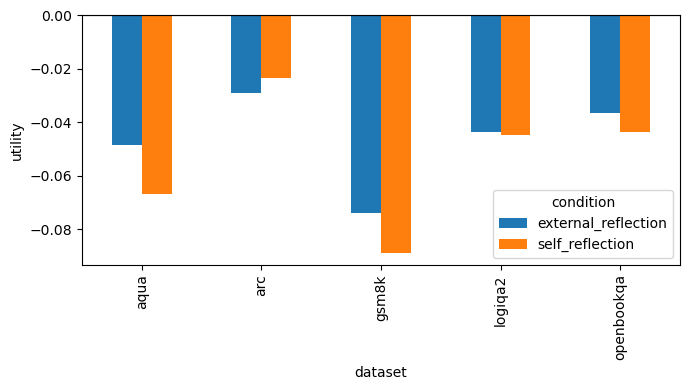

In [19]:
util_by_ds.plot(kind="bar")
plt.ylabel("utility")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Reflection utility por professor (reflexão externa)

Mesma métrica, só da condição `external_reflection`, separada por professor.

In [20]:
util_ext = util[util["condition"] == "external_reflection"].copy()
util_ext["teacher_label"] = util_ext["teacher"].map(display_teacher)
util_ext_by_ds = (
    util_ext.groupby(["dataset", "teacher_label"])["utility"]
    .mean().unstack("teacher_label").round(4)
)
util_ext_by_ds

teacher_label,llama3-8b,mistral-7b,phi4-mini,qwen3-8b
dataset,,,,
aqua,-0.0075,-0.0630,-0.0474,-0.0766
arc,-0.0006,-0.0242,-0.0238,-0.0679
gsm8k,-0.0466,-0.0441,-0.0718,-0.1336
logiqa2,-0.0115,-0.0503,-0.0455,-0.0674
openbookqa,-0.0190,-0.0277,-0.0343,-0.0653


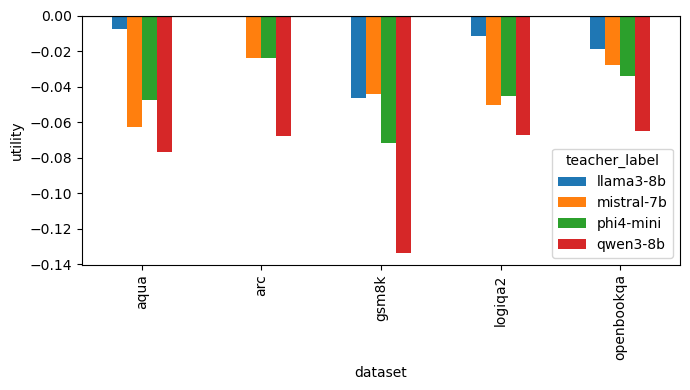

In [21]:
util_ext_by_ds.plot(kind="bar")
plt.ylabel("utility")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Transferability — utility × similaridade

Caderno: "a figura mais forte do paper". Utility da reflexão condicionada à faixa de cosseno entre
a questão de teste e a questão de treino que originou a reflexão recuperada.

In [22]:
trans = pd.read_csv(ANALYSIS / "transferability.csv")
trans_agg = (
    trans.groupby(["sim_lo", "sim_bin"])
    .apply(lambda g: (g["wrong_to_right"].sum() - g["right_to_wrong"].sum()) / g["n_shared"].sum())
    .reset_index(name="utility")
    .sort_values("sim_lo")
)
trans_agg

,sim_lo,sim_bin,utility
0,0.0,"[0.00, 0.60)",-0.049644
1,0.6,"[0.60, 0.70)",-0.046487
2,0.7,"[0.70, 0.80)",-0.054922
3,0.8,"[0.80, 0.90)",-0.083333
4,0.9,"[0.90, 1.01)",-0.062500


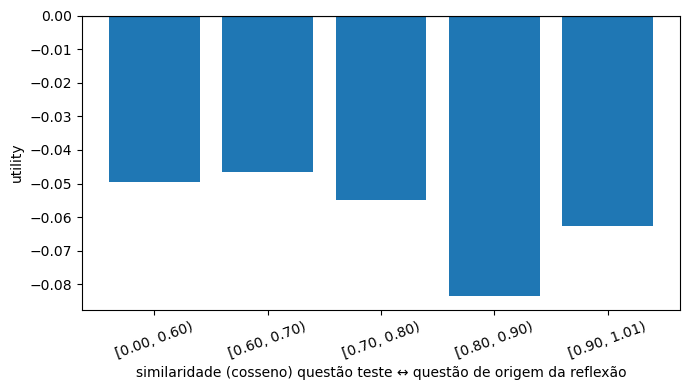

In [23]:
plt.bar(trans_agg["sim_bin"], trans_agg["utility"])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("utility")
plt.xlabel("similaridade (cosseno) questão teste ↔ questão de origem da reflexão")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Transferability por professor (reflexão externa)

Mesma figura, uma curva de utility × similaridade por professor — inclui o `gpt-5`.

In [24]:
trans_ext = trans[trans["condition"] == "external_reflection"].copy()
trans_ext["teacher_label"] = trans_ext["teacher"].map(display_teacher)
trans_ext_agg = (
    trans_ext.groupby(["teacher_label", "sim_lo", "sim_bin"])
    .apply(lambda g: (g["wrong_to_right"].sum() - g["right_to_wrong"].sum()) / g["n_shared"].sum())
    .reset_index(name="utility")
    .sort_values(["teacher_label", "sim_lo"])
)
trans_ext_pivot = trans_ext_agg.pivot(index="sim_bin", columns="teacher_label", values="utility")
trans_ext_pivot

teacher_label,llama3-8b,mistral-7b,phi4-mini,qwen3-8b
sim_bin,,,,
"[0.00, 0.60)",-0.019417,-0.048341,-0.050769,-0.077670
"[0.60, 0.70)",-0.017494,-0.038453,-0.043371,-0.082607
"[0.70, 0.80)",-0.022711,-0.037554,-0.050608,-0.098712
"[0.80, 0.90)",-0.033951,-0.074074,-0.067901,-0.179012
"[0.90, 1.01)",-0.037037,-0.111111,-0.055556,-0.074074


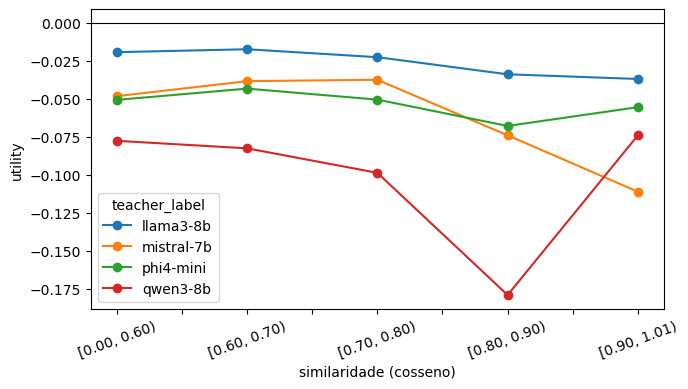

In [25]:
trans_ext_pivot.plot(marker="o")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("utility")
plt.xlabel("similaridade (cosseno)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Persistência de erro

Fração dos erros de treino cuja reflexão recuperada não evita o erro equivalente no teste.

In [26]:
pers = pd.read_csv(ANALYSIS / "persistence.csv")
pers.groupby(["dataset", "condition"])["error_persistence"].mean().unstack("condition").round(4)

condition,external_reflection,self_reflection
dataset,,
aqua,0.4508,0.4705
arc,0.1927,0.1799
gsm8k,0.3024,0.3198
logiqa2,0.4706,0.4681
openbookqa,0.2290,0.2302


### Persistência de erro por professor (reflexão externa)

In [27]:
pers_ext = pers[pers["condition"] == "external_reflection"].copy()
pers_ext["teacher_label"] = pers_ext["teacher"].map(display_teacher)
pers_ext.groupby(["dataset", "teacher_label"])["error_persistence"].mean().unstack("teacher_label").round(4)

teacher_label,llama3-8b,mistral-7b,phi4-mini,qwen3-8b
dataset,,,,
aqua,0.3836,0.3596,0.4930,0.5671
arc,0.1684,0.1479,0.1867,0.2678
gsm8k,0.2934,0.1562,0.3345,0.4254
logiqa2,0.4273,0.4504,0.4609,0.5437
openbookqa,0.2072,0.1854,0.2345,0.2891


### Custo por condição

Tokens de entrada/saída por questão de teste — necessário para comparar reflexão (gasta tokens de
entrada) com self-consistency (gasta tokens de saída).

In [28]:
cost = pd.read_csv(ANALYSIS / "cost.csv")
cost_test = cost[cost["split"] == "test"]
cost_summary = cost_test.groupby("condition").apply(lambda g: pd.Series({
    "tokens_entrada": (g["mean_prompt_tokens"] * g["n"]).sum() / g["n"].sum(),
    "tokens_saida": (g["mean_completion_tokens"] * g["n"]).sum() / g["n"].sum(),
}))
cost_summary["total"] = cost_summary["tokens_entrada"] + cost_summary["tokens_saida"]
cost_summary.round(1)

,tokens_entrada,tokens_saida,total
condition,,,
external_reflection,1278.6,293.0,1571.6
no_reflection,186.2,200.0,386.2
retry_feedback,185.2,188.0,373.2
self_reflection,1212.2,268.1,1480.3


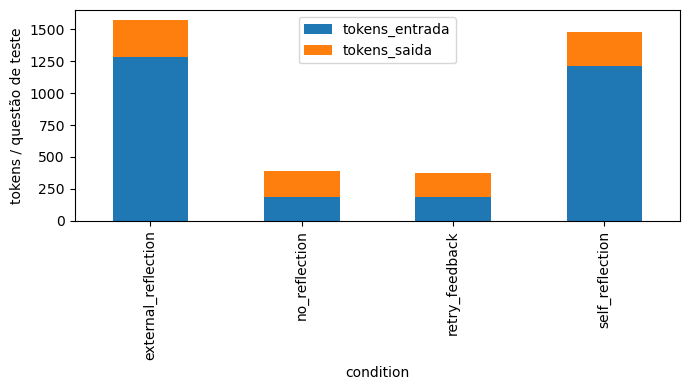

In [29]:
cost_summary[["tokens_entrada", "tokens_saida"]].plot(kind="bar", stacked=True)
plt.ylabel("tokens / questão de teste")
plt.tight_layout()
plt.show()

### Custo por professor (reflexão externa)

In [30]:
cost_ext = cost[(cost["condition"] == "external_reflection") & (cost["split"] == "test")].copy()
cost_ext["teacher_label"] = cost_ext["teacher"].map(display_teacher)
cost_ext_summary = cost_ext.groupby("teacher_label").apply(lambda g: pd.Series({
    "tokens_entrada": (g["mean_prompt_tokens"] * g["n"]).sum() / g["n"].sum(),
    "tokens_saida": (g["mean_completion_tokens"] * g["n"]).sum() / g["n"].sum(),
}))
cost_ext_summary["total"] = cost_ext_summary["tokens_entrada"] + cost_ext_summary["tokens_saida"]
cost_ext_summary.round(1)

,tokens_entrada,tokens_saida,total
teacher_label,,,
llama3-8b,1201.0,298.3,1499.3
mistral-7b,921.8,306.8,1228.6
phi4-mini,1262.7,273.9,1536.6
qwen3-8b,1729.1,293.0,2022.1


### Comprimento e diversidade por dataset

`results/analysis/reflections.csv` já agrega por `student × teacher × depth × dataset`; o paper só
tinha ARC, então a quebra por dataset abaixo é a extensão natural da seção 5.3/5.4 do paper.

In [31]:
refl_stats = pd.read_csv(ANALYSIS / "reflections.csv")
refl_stats.groupby(["dataset", "depth"])[["mean_words", "mean_ttr"]].mean().round(3)

mean_words  mean_ttr
dataset    depth                        
aqua       complex     424.850     0.509
           simple      147.075     0.655
arc        complex     387.588     0.528
           simple      138.069     0.684
gsm8k      complex     385.031     0.533
           simple      141.300     0.683
logiqa2    complex     425.562     0.506
           simple      157.494     0.656
openbookqa complex     387.381     0.535
           simple      133.494     0.696

### Não implementado

- **Redução de alucinações**: listada no Caderno (seção 5), mas nenhuma etapa do pipeline
  (`rmcq/stages/analyze.py`) define ou registra alucinação por linha — não há coluna
  correspondente em `results/`. Requer definir o critério de detecção antes de calcular; estrutura
  deixada em aberto para quando essa definição existir.